In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

_file = "/storage/emulated/0/Documents/CSVs/AfroSense Sales Data.xlsx"

afroSense_df = pd.read_excel(_file)

In [2]:
def load_inspect(df):
    _info = df.info()
    _nulls = df.isnull().any()
    _dups = df.duplicated().any()
    print(f"Dataset info: \n {_info} \n Null Check: \n {_nulls} Duplicates: \n {_dups}")
    return df

In [3]:
def df_clean(df):
    # Data Cleaning & Type Casting
    df['order_date'] = pd.to_datetime(df['order_date'])
    df['sales'] = pd.to_numeric(df['sales'], errors = 'coerce') 
    return df

In [4]:
def handle_nulls(df):
    # Handle nulls by filling with Mode for non-numeric columns and mean for numeric 
    null_cols = [col for col in df.columns if df[col].isnull().any()]
    
    report ={}
    for c in null_cols:
        if not pd.api.types.is_numeric_dtype(c):
            mod = df[c].mode()[0]
            df[c] = df[c].fillna(mod)
            report = {c: mod}
    print(f"Filled Nulls Report: \n{report}")  
    return df

In [5]:
def standardize_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
    return df

In [6]:
def rfm_clv(df):
    
    # Define the Snapshot Date (Usually the max date in dataset or current day)
    snapshot_date = pd.to_datetime('2026-09-19')
    # Define churn threshold days
    churn_threshold_days = 90 
    
    customer_activity = df.groupby('customer_id')['order_date'].max().reset_index()
    
    customer_activity.columns = ['customer_id', 'latest_order_date']
    
    customer_activity['days_since_last_purchase'] = (snapshot_date - customer_activity['latest_order_date']).dt.days
    
    customer_activity['is_churned'] = customer_activity['days_since_last_purchase']>churn_threshold_days
    
    total_customers = len(customer_activity)
    churned_customers = customer_activity['is_churned'].sum()
    churn_rate = (churned_customers / total_customers) * 100

    
    # Feature Selection: Roll up rows to individual Customer IDs
    rfm_matrix = df.groupby('customer_id').agg({
        # Recency: Days between the customer's last order date and the snapshot date
        'order_date': lambda x: (snapshot_date - x.max()).days,
        
        # Frequency: Total number of unique orders (not individual item rows)
        'order_id': 'nunique',
        
        # Monetary Value: Total Sales across all time
        'sales': 'sum'
    }).reset_index()
    
    # Rename Columns for Clarity
    rfm_matrix.columns = ['customer_id', 'recency', 'frequency', 'monetary']
    
    # Calculate Descriptive Statistic: Average Purchase Value (APV)
    rfm_matrix['APV'] = rfm_matrix['monetary'] / rfm_matrix['frequency']
    rfm_matrix['CLV'] = rfm_matrix['APV']* rfm_matrix['frequency']/ churn_rate
    
    # Merge static metadata back if needed for profile categorization later
    metadata = df[['customer_id', 'customer_name', 'segment']].drop_duplicates()
    temp_matrix = pd.merge(metadata, rfm_matrix, on='customer_id')
    final_profile_matrix = pd.merge(temp_matrix, customer_activity, on='customer_id')
    
    # Display the processed table ready for clustering
    return final_profile_matrix

In [7]:
def descriptive_df(df):
    total_sales = df["sales"].sum()
    total_orders = df["order_id"].nunique()
    print(f"Total Sales: {total_sales}\n Total Orders: {total_orders}")
    return df

In [8]:

def apply_customer_segmentation(profiles_df):
    """
    Normalises customer attributes, renders a visual line plot for the Elbow Method,
    and appends K-Means cluster classification labels back to the dataframe.
    """
    # Feature Selection
    features = ['recency', 'frequency', 'monetary']
    X = profiles_df[features].copy()
    
    # Scale Features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Calculate WCSS / Inertia for K 1 to 10
    wcss = []
    k_range = range(1, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
        
    # Render the Visual Elbow Plot directly inside the notebook
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, wcss, marker='o', linestyle='--', color='#2b6cb0', linewidth=2)
    plt.title('The Elbow Method for Optimal K Selection', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
    plt.xticks(k_range)
    
    # Highlight the typical optimal bend location visually
    plt.axvline(x=3, color='#e53e3e', linestyle=':', label='Typical Elbow Point (K=3)')
    plt.legend()
    plt.show()
    
    # Execute Final K-Means (Adjust n_clusters choice based on your line bend)
    optimal_k = 3 
    print(f"Applying K-Means algorithm with K={optimal_k}...")
    
    final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    profiles_df['cluster_label'] = final_kmeans.fit_predict(X_scaled)
    
    # Group and aggregate metrics to understand the clusters
    cluster_summary = profiles_df.groupby('cluster_label').agg({
        'recency': 'mean',
        'frequency': 'mean',
        'monetary': 'mean',
        'customer_id': 'count'
    }).rename(columns={'customer_id': 'customer_count'}).reset_index()
    
    print("\n" + "="*60)
    print("PROCESSED SEGMENTATION LAYER PROFILE")
    print("="*60)
    
    # Clean display mapping formatting for the summary table
    pd.options.display.float_format = '{:,.2f}'.format
    display(cluster_summary)
    
    return profiles_df

In [20]:
def execute_cluster_analytics_report(df):
    """
    Generates scatter subplots, customer profiling summaries, volume counts,
    and a strategic marketing insights framework for the customer clusters.
    """
    
    # -------------------------------------------------------------------------
    # PART 1: VISUALISE CLUSTERS USING SCATTER PLOTS (2 Feature Combinations)
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Combination A: Recency vs. Monetary Value
    sb.scatterplot(
        data=df, 
        x='recency', 
        y='monetary', 
        hue='cluster_label', 
        palette='Set1', 
        alpha=0.8, 
        ax=axes[0]
    )
    axes[0].set_title('Cluster Separation: Recency vs. Monetary', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Recency (Days Since Last Order)')
    axes[0].set_ylabel('Total Monetary Spend')
    axes[0].legend(title='Cluster Tiers')
    
    # Combination B: Frequency vs. Monetary Value
    sb.scatterplot(
        data=df, 
        x='frequency', 
        y='monetary', 
        hue='cluster_label', 
        palette='Set1', 
        alpha=0.8, 
        ax=axes[1]
    )
    axes[1].set_title('Cluster Separation: Frequency vs. Monetary', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequency (Total Unique Orders)')
    axes[1].set_ylabel('Total Monetary Spend')
    axes[1].legend(title='Cluster Tiers')
    
    plt.tight_layout()
    plt.show()
    
    # -------------------------------------------------------------------------
    # PART 2: BAR CHART (Number of Customers per Cluster)
    # -------------------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    ax = sb.countplot(
        data=df, 
        x='cluster_label', 
        palette='Set1',
        hue='cluster_label',
        legend=False
    )
    
    # Annotate total counts directly onto the bars for production reporting clarity
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')
                    
    plt.title('Distribution of Customer Accounts per Value Cluster', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Cluster Label')
    plt.ylabel('Total Distinct Customers')
    plt.show()

    # -------------------------------------------------------------------------
    # PART 3: PROFILE EACH CLUSTER (Calculate Mean Feature Values)
    # -------------------------------------------------------------------------
    cluster_profiles = df.groupby('cluster_label').agg({
        'recency': 'mean',
        'frequency': 'mean',
        'monetary': 'mean',
        'customer_id': 'count'
    }).rename(columns={'customer_id': 'customer_count'}).reset_index()
    
    print("=" * 70)
    print("NUMERICAL PROFILE BREAKDOWN PER CLUSTER")
    print("=" * 70)
    pd.options.display.float_format = '{:,.2f}'.format
    display(cluster_profiles)
    print("\n" + "=" * 70)
    
    # -------------------------------------------------------------------------
    # PART 4: INSIGHTS & MARKETING ACTION RECOMMENDATIONS
    # -------------------------------------------------------------------------
    print("STRATEGIC MARKETING INSIGHTS REPORT")
    print("=" * 70)
    
    # Dynamic description logic mapped out based on standard RFM cluster distribution characteristics
    for idx, row in cluster_profiles.iterrows():
        cluster_num = int(row['cluster_label'])
        rec = row['recency']
        freq = row['frequency']
        mon = row['monetary']
        
        print(f"\n▶ [CLUSTER #{cluster_num}] ")
        
        # Profile heuristic categorization routing
        if freq > cluster_profiles['frequency'].mean() and rec < cluster_profiles['recency'].mean():
            print("  - Customer Type: Core Champions / VIP Accounts")
            print(f"  - Characteristics: Low Recency ({rec:.1f} days), High Frequency ({freq:.1f} orders), High Value.")
            print("  - Strategic Recommendation:")
            print("    * Implement loyalty reward access and exclusive early-product previews.")
            print("    * Avoid heavy discount bundling; focus on high-value cross-selling and premium upgrades.")
            
        elif rec > cluster_profiles['recency'].mean():
            print("  - Customer Type: Churn Risk / At-Risk Inactive Cohort")
            print(f"  - Characteristics: Long Inactivity ({rec:.1f} days), Modest Spend, Weak Engagement.")
            print("  - Strategic Recommendation:")
            print("    * Trigger automated high-incentive win-back e-mail pipelines containing limited-time vouchers.")
            print("    * Deploy tailored survey diagnostics to determine point of exit or system delivery failure.")
            
        else:
            print("  - Customer Type: Promising New / Mid-Tier Midrange Accounts")
            print(f"  - Characteristics: Low Recency ({rec:.1f} days), Low-to-Med Frequency ({freq:.1f} orders).")
            print("  - Strategic Recommendation:")
            print("    * Launch educational cross-channel welcome sequences showing related top-category products.")
            print("    * Offer targeted bundles on their second purchase window to solidify transaction frequency.")

In [9]:
load_inspect(afroSense_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51300 entries, 0 to 51299
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51300 non-null  int64         
 1   Order ID        51300 non-null  object        
 2   Order Date      51300 non-null  datetime64[ns]
 3   Ship Date       51300 non-null  datetime64[ns]
 4   Ship Mode       51300 non-null  object        
 5   Customer ID     51300 non-null  object        
 6   Customer Name   51300 non-null  object        
 7   Segment         51300 non-null  object        
 8   Postal Code     9998 non-null   float64       
 9   City            51300 non-null  object        
 10  State           51300 non-null  object        
 11  Country         51300 non-null  object        
 12  Region          51300 non-null  object        
 13  Market          51300 non-null  object        
 14  Product ID      51300 non-null  object        
 15  Ca

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.770,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.630,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.490,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.160,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.040,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51295,29002,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,NaN,Kure,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,1.010,Medium
51296,34337,US-2014-ZD21925140-41765,2014-05-06,2014-05-10,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,37421.0,Chattanooga,...,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16.720,5,0.2,3.3440,1.930,High
51297,31315,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,94109.0,San Francisco,...,OFF-AR-5321,Office Supplies,Art,Newell 341,8.560,2,0.0,2.4824,1.580,High
51298,9596,MX-2013-RB1979518-41322,2013-02-17,2013-02-21,Standard Class,RB-1979518,Ross Baird,Home Office,NaN,Valinhos,...,OFF-BI-2919,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,1.003,Medium


In [10]:
standardized = standardize_cols(afroSense_df)

In [11]:
cleaned = df_clean(standardized)

In [13]:
null_clean = handle_nulls(cleaned)
null_clean

Filled Nulls Report: 
{'postal_code': np.float64(10035.0)}


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,postal_code,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.770,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,10035.0,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.630,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,10035.0,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.490,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,10035.0,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.160,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,10035.0,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.040,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51295,29002,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,10035.0,Kure,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,1.010,Medium
51296,34337,US-2014-ZD21925140-41765,2014-05-06,2014-05-10,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,37421.0,Chattanooga,...,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16.720,5,0.2,3.3440,1.930,High
51297,31315,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,94109.0,San Francisco,...,OFF-AR-5321,Office Supplies,Art,Newell 341,8.560,2,0.0,2.4824,1.580,High
51298,9596,MX-2013-RB1979518-41322,2013-02-17,2013-02-21,Standard Class,RB-1979518,Ross Baird,Home Office,10035.0,Valinhos,...,OFF-BI-2919,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,1.003,Medium


In [17]:
customer_profiles = rfm_clv(null_clean)
customer_profiles

,customer_id,customer_name,segment,recency,frequency,monetary,APV,CLV,latest_order_date,days_since_last_purchase,is_churned
0,AB-100151402,Aaron Bergman,Consumer,4330,2,576.564,288.2820,5.76564,2014-11-11,4330,True
1,JR-162107,Justin Ritter,Corporate,3980,3,4550.931,1516.9770,45.50931,2015-10-27,3980,True
2,CR-127307,Craig Reiter,Consumer,4355,2,5907.951,2953.9755,59.07951,2014-10-17,4355,True
3,KM-1637548,Katherine Murray,Home Office,4025,2,4309.902,2154.9510,43.09902,2015-09-12,4025,True
4,RH-9495111,Rick Hansen,Consumer,4336,1,2832.960,2832.9600,28.32960,2014-11-05,4336,True
...,...,...,...,...,...,...,...,...,...,...,...
17410,ZD-219251408,Zuschuss Donatelli,Consumer,4455,2,890.104,445.0520,8.90104,2014-07-09,4455,True
17411,ZD-219251404,Zuschuss Donatelli,Consumer,4117,2,323.320,161.6600,3.23320,2015-06-12,4117,True
17412,ZD-219251402,Zuschuss Donatelli,Consumer,4551,1,331.080,331.0800,3.31080,2014-04-04,4551,True
17413,AS-285147,Alejandro Savely,Corporate,5296,1,9.612,9.6120,0.09612,2012-03-20,5296,True


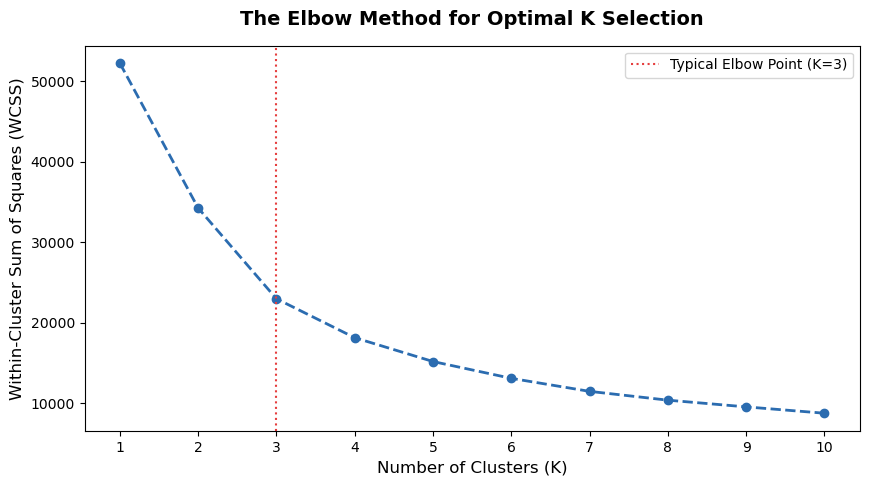

Applying K-Means algorithm with K=3...

PROCESSED SEGMENTATION LAYER PROFILE


,cluster_label,recency,frequency,monetary,customer_count
0,0,"4,188.18",1.25,446.95,8952
1,1,"4,167.95",3.00,"2,177.85",2755
2,2,"4,911.59",1.10,462.82,5708


In [18]:
 segmented_profiles = apply_customer_segmentation(customer_profiles)
    

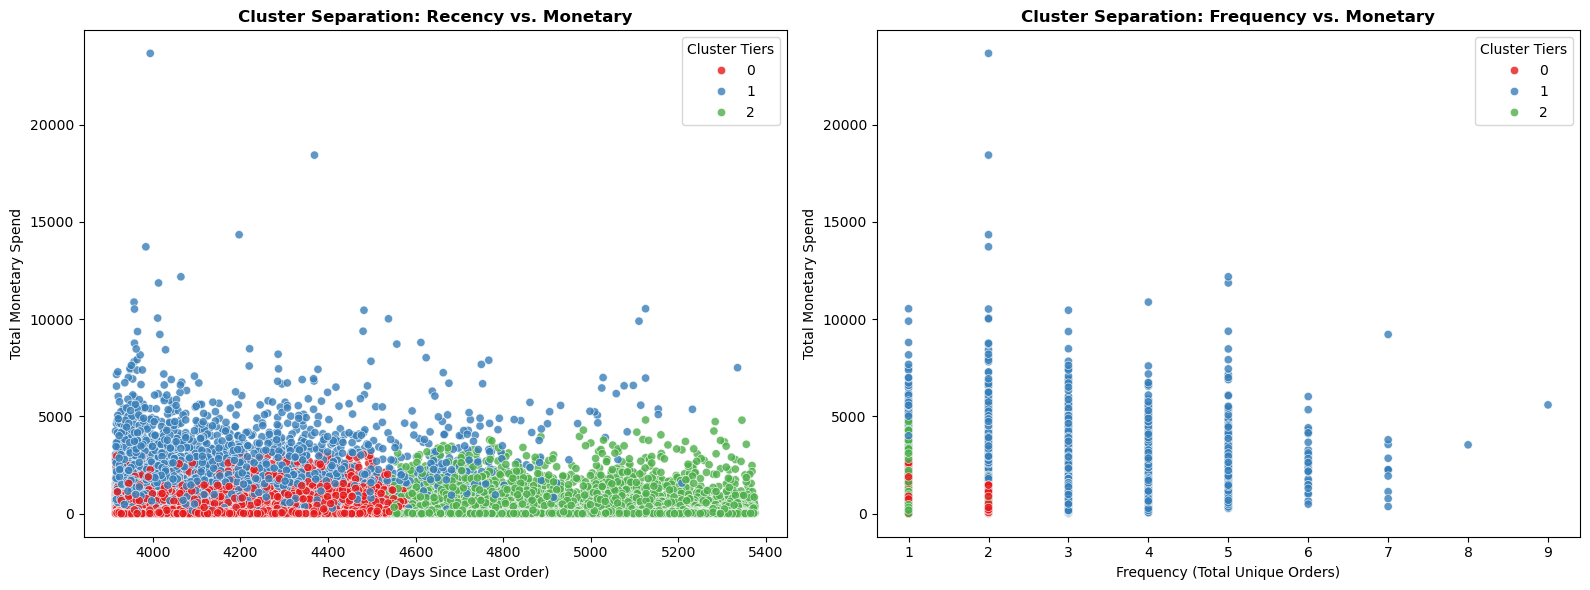

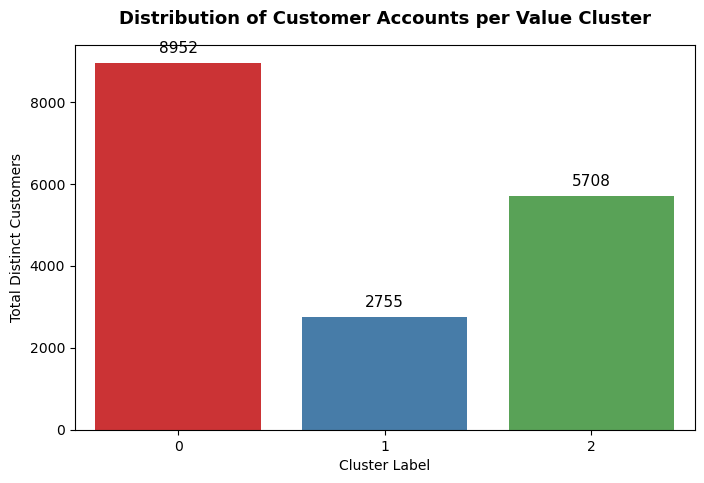

NUMERICAL PROFILE BREAKDOWN PER CLUSTER


,cluster_label,recency,frequency,monetary,customer_count
0,0,"4,188.18",1.25,446.95,8952
1,1,"4,167.95",3.00,"2,177.85",2755
2,2,"4,911.59",1.10,462.82,5708



STRATEGIC MARKETING INSIGHTS REPORT

▶ [CLUSTER #0] 
  - Customer Type: Promising New / Mid-Tier Midrange Accounts
  - Characteristics: Low Recency (4188.2 days), Low-to-Med Frequency (1.3 orders).
  - Strategic Recommendation:
    * Launch educational cross-channel welcome sequences showing related top-category products.
    * Offer targeted bundles on their second purchase window to solidify transaction frequency.

▶ [CLUSTER #1] 
  - Customer Type: Core Champions / VIP Accounts
  - Characteristics: Low Recency (4168.0 days), High Frequency (3.0 orders), High Value.
  - Strategic Recommendation:
    * Implement loyalty reward access and exclusive early-product previews.
    * Avoid heavy discount bundling; focus on high-value cross-selling and premium upgrades.

▶ [CLUSTER #2] 
  - Customer Type: Churn Risk / At-Risk Inactive Cohort
  - Characteristics: Long Inactivity (4911.6 days), Modest Spend, Weak Engagement.
  - Strategic Recommendation:
    * Trigger automated high-incentive 

In [21]:
execute_cluster_analytics_report(segmented_profiles)